In [3]:
#1. Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [5]:
#2. Load Dataset
df = pd.read_excel("/content/Online Retail.xlsx")

# Preview
print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  


In [6]:
# 3. Data Cleaning
# Remove missing CustomerID
df = df.dropna(subset=['CustomerID'])

# Remove negative or zero values
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# Convert CustomerID to integer
df['CustomerID'] = df['CustomerID'].astype(int)

In [7]:
# 4. Create CLV (Target Variable)
# Create Total Amount per transaction
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

# Aggregate to customer level (CLV)
clv_df = df.groupby('CustomerID').agg({
    'TotalAmount': 'sum',
    'InvoiceNo': 'nunique',
    'Quantity': 'sum'
}).reset_index()

# Rename columns
clv_df.columns = ['CustomerID', 'CLV', 'Frequency', 'TotalQuantity']

In [8]:
# 5. Feature Engineering (Important for Marks)
# Average order value
clv_df['AvgOrderValue'] = clv_df['CLV'] / clv_df['Frequency']

# Quantity per order
clv_df['QtyPerOrder'] = clv_df['TotalQuantity'] / clv_df['Frequency']

In [9]:
# 6. Define Features & Target
X = clv_df.drop(['CustomerID', 'CLV'], axis=1)
y = clv_df['CLV']

In [10]:
# 7. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
# 8. Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [12]:
# 9. Predictions
y_pred = model.predict(X_test)

In [13]:
# 10. Model Evaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)

RMSE: 5524.577965471686
MAE: 568.2388147321298
R2 Score: 0.7020683523607318


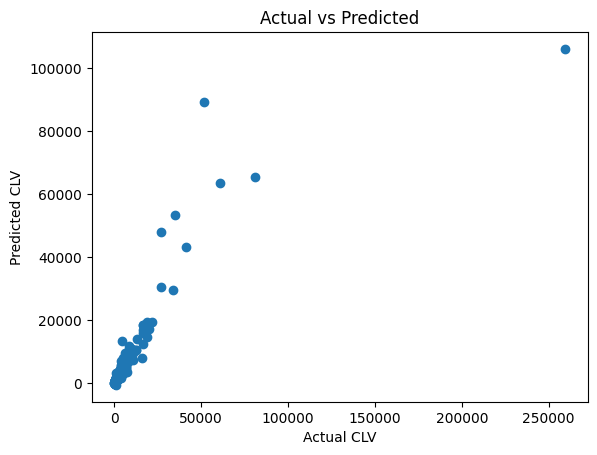

In [14]:
# 11. Assumption Checks
# Linearity
plt.scatter(y_test, y_pred)
plt.xlabel("Actual CLV")
plt.ylabel("Predicted CLV")
plt.title("Actual vs Predicted")
plt.show()

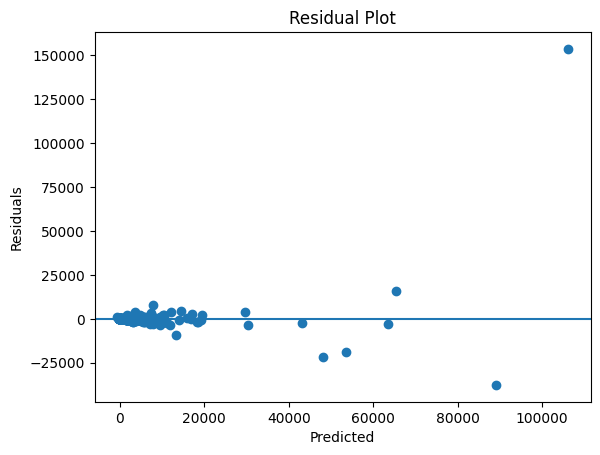

In [15]:
# Homoscedasticity
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [16]:
# Multicollinearity (VIF)
X_vif = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print(vif_data)

         Feature       VIF
0          const  1.409186
1      Frequency  1.572367
2  TotalQuantity  1.882608
3  AvgOrderValue  7.700536
4    QtyPerOrder  7.503994
